## **Describing a Single Set of Data**

In [19]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# num_friends = [
#     6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 
#     12, 12, 13, 13, 14, 14, 15, 15, 16, 17, 18, 18, 19, 20, 21, 22, 
#     23, 24, 25, 26, 27, 28, 30, 31, 33, 34, 36, 37, 39, 41, 42, 44, 
#     46, 48, 50, 52, 54, 56, 59, 61, 63, 66, 68, 71, 73, 76, 79, 81, 
#     84, 87, 89, 92, 95, 98, 100, 100, 99, 97, 96, 94, 93, 91, 89, 88, 
#     86, 85, 83, 82, 80, 78, 77, 75, 74, 72, 71, 70, 69, 68, 67, 66
# ]



num_friends = [
    19, 90, 56, 39, 8, 8, 6, 76, 39, 53, 6, 94, 71, 10, 9, 9, 14, 31, 23, 13, 
    41, 7, 14, 18, 25, 63, 9, 30, 38, 6, 40, 8, 6, 90, 93, 67, 14, 6, 50, 24, 
    7, 29, 6, 83, 12, 47, 15, 31, 34, 9, 94, 62, 88, 81, 39, 85, 6, 9, 6, 15, 
    20, 12, 70, 17, 13, 33, 7, 66, 6, 97, 62, 9, 6, 68, 52, 55, 61, 6, 18, 7, 
    76, 42, 16, 6, 15, 15, 56, 44, 79, 26, 7, 53, 60, 35, 61, 28, 31, 23, 6, 7, 
    6, 44, 15, 30, 83, 11, 21, 59, 10, 6, 13, 8, 87, 67, 43, 77, 66, 9, 80, 33, 
    67, 81, 15, 7, 10, 23, 68, 75, 6, 30, 22, 10, 7, 16, 89, 15, 31, 52, 18, 94, 
    93, 11, 29, 14, 13, 6, 40, 29, 6, 13, 83, 11, 7, 28, 97, 11, 48, 60, 11, 55, 
    18, 43, 43, 32, 6, 71, 15, 9, 6, 38, 49, 6, 30, 10, 45, 8, 50, 20, 88, 7, 
    16, 7, 86, 78, 12, 46, 68, 34, 32, 11, 6, 81, 82, 43, 16, 17, 55, 81, 79, 63
]

label = [i for i in range(len(num_friends))]

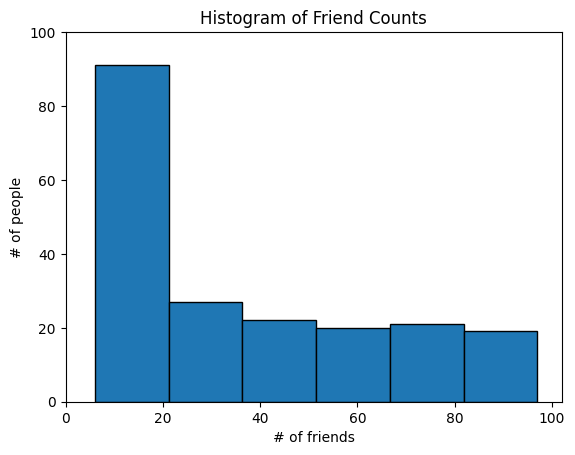

In [44]:
plt.hist(num_friends, bins='fd', edgecolor='black')
plt.axis([0, max(num_friends)+5, 0, 100])
plt.title("Histogram of Friend Counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")

plt.show()

In [45]:
num_point = len(num_friends) # shape of data

num_point

200

In [46]:
largest_value = max(num_friends)
smallest_value = min(num_friends)

largest_value, smallest_value 

(97, 6)

### **Central Tendencies**

In data science, **central tendency** refers to a single value that attempts to describe a set of data by identifying the central position within that dataset. These are the "summary statistics" you use to understand the "typical" or "middle" behavior of your data before performing deeper analysis.

As you develop your **Comptoire-DWH** and implement data pipelines, these measures serve as your first line of defense for data profiling.

- **The Big Three**

| Measure | What it represents | Best Use Case |
| :--- | :--- | :--- |
| **Mean** | The arithmetic average (the "balance point"). | Symmetrical numerical data without outliers. |
| **Median** | The middle value (the 50th percentile). | Skewed data (e.g., income, house prices). |
| **Mode** | The most frequent value. | Categorical data or discrete frequency analysis. |

---

- **Why this matters for Data Engineering**
    - In the context of your data architecture (Bronze $\rightarrow$ Silver $\rightarrow$ Gold):

* **Bronze Layer (Ingestion):** You use **Mode** and counts to identify categorical distributions and detect anomalies in data types or unexpected nulls.
* **Silver Layer (Cleansing/Transformation):** You use the **Median** to handle outliers or impute missing values, as it is more robust than the mean.
* **Gold Layer (Reporting/Analytics):** You use the **Mean** to provide stakeholders with the average performance metrics of the business.

- **Beyond the Basics: Quantiles**
    - While Mean, Median, and Mode provide a single point of reference, **Quantiles** (like quartiles or percentiles) allow you to understand the **spread** of your data.

* **Interquartile Range (IQR):** By calculating the 25th ($Q1$) and 75th ($Q3$) percentiles, you define the "middle 50%" of your data. This is the standard data engineering approach for identifying outliers (any data point $> Q3 + 1.5 \times \text{IQR}$ is typically flagged).

In [20]:
from typing import List

In [48]:
def mean(xs: List[float]) -> float:
    return sum(xs) / len(xs)

In [49]:
mean(num_friends)

35.64

In data science, the **mean** (arithmetic average) is the most fundamental measure of central tendency. It provides a single value that represents the "center" or "balance point" of your dataset.

- **The Mathematical Definition**
    - The mean is calculated by summing all the values in a dataset and dividing by the total count of values. For a dataset $x$ with $n$ elements, the mean ($\bar{x}$) is:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$



- **Why the Mean Matters in Data Engineering**
    - As you build your **Medallion architecture** (Bronze/Silver/Gold), you will frequently use the mean for data quality checks and feature engineering:
        * **Imputation:** When handling missing data in your "Silver" layer, the mean is a standard way to fill gaps—though you must be careful if the data is skewed.
        * **Normalization:** You often subtract the mean from your features to center your data around zero, which is a required step before feeding data into many machine learning algorithms.

- **Important Caveats**
    - While the mean is useful, it has a significant vulnerability that you must account for in your pipelines: **Sensitivity to Outliers**.

Because the mean incorporates every single value in the sum, a few extremely high or low values (outliers) can "pull" the mean away from the true center.

* **Example:** Imagine a small startup where most employees make \$50k. If the CEO earns \$5M, the "mean" salary will suggest everyone is a millionaire, which is a poor representation of the actual employee experience.
* **Data Science Strategy:** In your Data Warehouse (DWH) transformations, if you detect that your data is heavily skewed (e.g., via a histogram), it is often better to use the **median** (the middle value) instead of the mean to represent central tendency.


In [80]:
def _median_odd(xs: List[float]) -> float:
    """If len(xs) is odd, the median is the middle element"""
    
    return sorted(xs)[len(xs) // 2]

In [81]:
def _median_even(xs: List[float]) -> float:
    """If len(xs) is even, it's the average of the middle two elements"""
    index = len(xs) // 2
    
    return (sorted(xs)[index] + sorted(xs)[index-1]) / 2

In [82]:
def median(xs: List[float]) -> float:
    """Finds the 'middle-most' value of v"""
    
    return _median_odd(xs) if len(xs) % 2 != 0 else _median_even(xs)

In [74]:
median(num_friends)

28.5

In [76]:
median([1, 10, 2, 9, 5]), median([1, 9, 2, 10])

(5, 5.5)

The **median** is the "middle" value of a dataset when it is ordered from smallest to largest. Unlike the mean, which is sensitive to every single value, the median focuses on the **position** of the data.

- **How to Calculate**
    1.  **Sort the data:** Arrange the dataset in ascending order.
    2.  **Find the middle:**
        * If the number of elements ($n$) is **odd**, the median is the value at the exact middle position.
        * If $n$ is **even**, the median is the average of the two middle values.


- **Why the Median is Powerful**
    - In data science, the median is considered a **robust statistic**. 

* **Resistance to Outliers:** Because the median only cares about the middle position, adding a massive outlier (e.g., a CEO's salary) to a dataset won't drastically shift the median. This makes it a far more "honest" representation of the center for skewed distributions, such as income, housing prices, or website response times.
* **Data Integrity:** When you are cleaning data for your Silver layer in a Medallion architecture, using the median to fill missing values is often safer than the mean, as it is less likely to introduce bias into your dataset.

- **Comparison: Mean vs. Median**

| Feature | Mean | Median |
| :--- | :--- | :--- |
| **Sensitivity** | Highly sensitive to outliers | Highly resistant to outliers |
| **Calculation** | Uses all data points | Uses only middle positional data |
| **Best For** | Symmetric (normal) distributions | Skewed distributions |

> There are, in fact, nonobvious tricks to efficiently [**compute medians**](https://en.wikipedia.org/wiki/Quickselect) without sorting the data. However, they are beyond the scope of this book, so we have to sort the data.

In [95]:
def quantile(xs: List[float], i: float) -> float:
    """Returns the pth-percentile value in x"""
    
    p_index= int(len(xs) * i)
    return sorted(xs)[p_index]

In [96]:
quantile(num_friends, 0.25), quantile(num_friends, 0.20), quantile(num_friends, 0.75)

(10, 9, 60)

In [93]:
median(num_friends)

28.5

While the **mean** and **median** provide a single "center" point, **quantiles** allow you to slice your data into intervals to understand its entire distribution.

- **What is a Quantile?**
    - A quantile is a cutoff point that divides a sorted dataset into equal-sized groups. If you imagine your data sorted in a line, quantiles are the markers you place along that line.

* **Percentiles** are the most common form of quantiles, dividing data into 100 parts (0 to 100).
* **Quartiles** divide data into 4 parts (25%, 50%, 75%).
* **Deciles** divide data into 10 parts.



![Image of a box plot showing quartiles and median](../Images/Quantile.jpeg)


- **The Relationship to Median**
    - You already know the **median** is the middle value. In quantile terminology, the median is exactly the **0.50 quantile** (or the 50th percentile). It is the point below which 50% of your data falls.

- **Why Data Scientists Use Quantiles**
    - Quantiles are essential for advanced data analysis and preparing data for ML models:
        1.  **Detecting Outliers:** A common technique is to define an "interquartile range" (IQR), which is the distance between the 25th percentile ($Q1$) and the 75th percentile ($Q3$). Any data point falling significantly outside this range (usually $1.5 \times \text{IQR}$) can be flagged as an outlier.
        2.  **Handling Skewness:** If your data is heavily skewed, quantiles help you understand the *shape* of the distribution better than a mean ever could.
        3.  **Binning/Bucketing:** In feature engineering, you might convert continuous variables (like "Income") into ordinal categories (like "Low-Income Bracket", "Mid-Income", "High-Income") based on quantile thresholds.

- **Python Implementation (using NumPy)**
    - In your `Comptoire-DWH` project, you will likely use `numpy` or `pandas` to calculate these efficiently:

```python
import numpy as np

data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Calculate the 25th, 50th (median), and 75th percentiles
q1, q2, q3 = np.quantile(data, [0.25, 0.50, 0.75])

print(f"25th Percentile (Q1): {q1}")
print(f"50th Percentile (Median): {q2}")
print(f"75th Percentile (Q3): {q3}")
```

- **The "Big Picture"**
    * **Mean:** Where is the balance point?
    * **Median:** Where is the middle?
    * **Quantiles:** How is the data spread out across the entire range?

By using these three concepts together, you can perform a thorough **Exploratory Data Analysis (EDA)** before you even begin training a model or building a complex pipeline.

In [97]:
from collections import Counter

In [101]:
def mode(xs: List[float]) -> List[int]:
    """Returns a list, since there might be more than one mode"""
    friend_counter = Counter(xs)
    max_counter = max(friend_counter.values())

    return [ x_i for x_i, count in friend_counter.items() if count == max_counter]


In [103]:
mode(num_friends)

[6]

The **mode** is the final member of the central tendency trio. While the mean focuses on the "average" and the median focuses on the "middle," the **mode** focuses on **frequency**.

- **What is the Mode?**
    - The mode is simply the value that appears **most frequently** in a dataset. 

* **Unimodal:** A dataset with one clear, most frequent value.
* **Bimodal/Multimodal:** A dataset where two or more values appear with the same maximum frequency.
* **No Mode:** If every value appears only once, the dataset has no mode.



- **Why Data Scientists Use the Mode**
    - Unlike the mean and median, which are purely numerical, the mode is the **only measure of central tendency that works for categorical (nominal) data.**

* **Categorical Insight:** If you are analyzing a column in your data warehouse like `User_Country` or `Product_Category`, you cannot calculate a mean or a median. The mode tells you the most popular category, which is vital for business intelligence.
* **Data Quality (Profiling):** In your data engineering pipelines, calculating the mode is an excellent way to identify "typical" behavior. If you are processing server logs and the mode of `Status_Code` is `200`, your system is healthy. If the mode suddenly shifts to `500`, you have an immediate data quality or system alert.

- **Comparison Summary**

| Tendency | Focus | Best For |
| :--- | :--- | :--- |
| **Mean** | The balance point | Symmetric numerical data |
| **Median** | The physical center | Skewed numerical data |
| **Mode** | The most frequent occurrence | Categorical or discrete data |

### **Dispersion**

In data science, **dispersion measures** (or measures of variability) quantify how "spread out" or clustered your data points are. While measures of central tendency (mean, median, mode) tell you where the "center" of your data is, dispersion measures describe the **reliability** and **consistency** of that center.


- **Why Dispersion Matters**
    - If you are building a machine learning model, dispersion is critical:
        * **Predictability:** A dataset with low dispersion around the mean is more predictable. A high dispersion often implies higher noise or underlying volatility.
        * **Outlier Detection:** Dispersion measures are the primary way to identify statistical anomalies.
        * **Feature Scaling:** Many algorithms (like SVMs or K-Means) require features to be scaled based on their dispersion (Standard Deviation) so that one feature doesn't dominate the others just because of its larger range.

---

- **The Primary Measures of Dispersion**

| Measure | Definition | Best For |
| :--- | :--- | :--- |
| **Range** | Difference between max and min values. | Initial "sanity check" for bounds. |
| **Variance** | Average of squared differences from the mean. | Foundational math for predictive modeling. |
| **Standard Deviation** | Square root of the variance. | Interpretable "typical" spread in original units. |
| **Interquartile Range (IQR)** | Distance between the 75th and 25th percentiles. | Robust analysis of skewed data or outliers. |

---

- **Understanding the Trade-offs**

- **1. Range (The Simple View)**
    - The range gives you the total span of your data. However, it is **highly sensitive to outliers**. If your dataset is 99% values between 10 and 20, but one value is 500, the range will tell you the data is "spread out" across 490 units, which is misleading.

- **2. Variance & Standard Deviation (The Statistical View)**
    - These measure how much, on average, each point deviates from the mean.
        * **Variance ($\sigma^2$)** is mathematically convenient for formulas but uses squared units (e.g., dollars squared).
        * **Standard Deviation ($\sigma$)** is the most popular because it brings the scale back to the original units (e.g., dollars), making it easier to explain to stakeholders.

- **3. Interquartile Range - IQR (The Robust View)**
    - When you have heavily skewed data (like income or website traffic), the **IQR** is your best friend. It focuses on the "middle 50%" of your data, completely ignoring the extremes.

---

- **Practical Application for Data Science Students**
    - When you are performing Exploratory Data Analysis (EDA) on a new dataset, you should always look at these together:
        1.  **Check the Range:** Do the min/max values make sense? (Data cleaning step).
        2.  **Compare Mean vs. Median:** Are they close? If not, use **IQR** for spread.
        3.  **Use Standard Deviation:** If the data is normally distributed, use this to determine what counts as an "unusual" value (Z-score).

#### **Range**

The **range** is the simplest and most intuitive measure of dispersion. It represents the total span of your data by calculating the difference between the maximum and minimum values in a dataset.

- **The Formula**
$$\text{Range} = \text{Maximum Value} - \text{Minimum Value}$$

---

- **Why Data Scientists Use It**
    - While it is the crudest measure of dispersion, it serves specific purposes in your data science workflow:
        * **Quick Health Check:** In your initial **Exploratory Data Analysis (EDA)**, you can use the range to perform "sanity checks." If you are analyzing a dataset that should logically fall between 0 and 100, a range calculation will immediately tell you if your data contains impossible values that need cleaning.
        * **Defining Boundaries:** The range helps you understand the absolute limits of your data. If your range is unexpectedly large, it indicates the presence of extreme outliers that might significantly bias your mean or distort your predictive models.

---

- **The Limitation: Sensitivity**
    - The range is **extremely sensitive to outliers**. If you have a dataset of 1,000 values all clustered between 10 and 20, but one single value is 500, your range is $500 - 10 = 490$. This makes the range suggest a massive spread, even though 99.9% of your data is very tightly packed.

Because of this, data scientists rarely use the range as their *only* measure of dispersion. They almost always pair it with more robust metrics:

| Metric | Sensitivity to Outliers | Use Case |
| :--- | :--- | :--- |
| **Range** | Extremely High | Rough sanity checks, boundary validation |
| **IQR (Interquartile Range)** | Low | Understanding spread of the "core" data |
| **Standard Deviation** | Moderate | Statistical modeling and anomaly detection |

---

- **Python Implementation**
    - In your own data analysis scripts, implementing this is straightforward:

```python
data = [10, 15, 12, 18, 100] # 100 is an outlier

# Calculate range
data_range = max(data) - min(data)

print(f"The range is: {data_range}") # Result: 90
```

In [104]:
def data_range(xs: List[float]) -> float:
    return max(xs) - min(xs)

In [105]:
data_range(num_friends)

91

#### **Variance**

**Variance** is the average of the squared differences between each data point and the mean. While the range tells you the total distance between the extremes, variance tells you how "spread out" the *entire* dataset is relative to its center.

- **The Mathematical Intuition**
    - To calculate variance ($\sigma^2$), you follow these steps:
        1.  Find the mean ($\bar{x}$).
        2.  Subtract the mean from every individual value and square the result (this ensures all differences are positive and emphasizes larger outliers).
        3.  Average those squared differences.

---

- **Why Variance Matters for Data Science**
    - Variance is much more than a descriptive statistic; it is a **foundational building block** for predictive modeling:
        * **Measuring Uncertainty:** High variance means your data is volatile and unpredictable. Low variance means your data is stable and consistent.
        * **Feature Selection:** In Machine Learning, if a feature has zero or very low variance (e.g., a column where 99% of values are the same), it contains almost no useful information. Data scientists often drop these "low-variance" features to reduce noise.
        * **Optimization:** Many algorithms work by trying to **minimize variance** (the error) in predictions. For example, in regression, you are effectively trying to find a line that minimizes the variance of the residuals (the differences between predicted and actual values).

---

- **Variance vs. Standard Deviation**
    - You will notice that variance is always in "squared" units (e.g., if your data is in dollars, variance is in dollars-squared). This makes it hard to interpret directly.

* **Standard Deviation ($\sigma$):** Is simply the square root of the variance ($\sqrt{\sigma^2}$). It brings the measurement back to the original units of your data, making it much more interpretable for reporting to stakeholders.

---

- **Python Implementation**
    - Since you are a Data Science student, you will likely use `numpy` to calculate this efficiently, as it is highly optimized for vector operations:

```python
import numpy as np

# Sample data
data = [10, 20, 30, 40, 50]

# Calculate variance (ddof=1 for sample variance)
variance = np.var(data, ddof=1)

# Calculate standard deviation
std_dev = np.std(data, ddof=1)

print(f"Variance: {variance}") # 250.0
print(f"Standard Deviation: {std_dev}") # 15.81
```

In [8]:
import math

In [40]:
def mean(xs: List[float]) -> float:
    """Calculate the mean of dataset"""

    return sum(xs) / len(xs)

def scaler_sub(xs: List[float]) -> List[float]:
    """substracte the mean from each point in dataset"""

    return [ math.pow((xs_i - mean(xs)), 2) for xs_i in xs]

def variance(xs: List[float]) -> float:
    """Almost the average squared deviation from the mean"""

    assert len(xs) > 2, "to calculate variance require at least two element"

    return sum(scaler_sub(xs)) / len(xs)

In [41]:
variance(num_friends)

798.9703999999997

This is one of the most famous "Aha!" moments in statistics. It centers on the difference between describing a dataset you fully possess (a population) and estimating truths about a dataset you only partially see (a sample).

- **The Core Problem: The "Underestimate" Bias**
    - When you calculate variance using the entire population, you divide by $n$. This gives you the *exact* variance of that set.

However, in Data Science, we rarely have the whole population. We have a **sample**.

1.  **The "Fixed" Mean:** When you calculate the sample mean ($\bar{x}$), it is calculated *using* your specific sample data. Because $\bar{x}$ is perfectly centered to minimize the distance to those specific points, it is naturally closer to them than the true (unknown) population mean would be.
2.  **The Resulting Shrinkage:** Because your sample mean is "chasing" your sample points, the squared distances $(x_i - \bar{x})^2$ are, on average, smaller than the true distances would be against the actual population mean.
3.  **The Correction:** If you divided by $n$, you would consistently calculate a variance that is too small (a "biased" estimator). By dividing by **$n - 1$** (a technique known as **Bessel’s Correction**), you make the denominator smaller, which makes the final result slightly larger. This effectively compensates for the bias and gives you an **unbiased estimate** of the population variance.

---

- **Why $n-1$? (Degrees of Freedom)**
    - Think of this as "Degrees of Freedom." 
        * If you have $n$ data points, you have $n$ independent pieces of information.
        * However, to calculate the variance, you *must* first calculate the mean ($\bar{x}$). Once you have the mean, the final data point in your set is no longer "free" to be any value—it is locked in by the requirement that the set must sum to $n \times \bar{x}$.
        * Because one "degree of freedom" was used up to calculate the mean, you are left with $n - 1$ independent pieces of information to estimate the variance.

---

- **The "Data Science Student" Rule of Thumb**
    - As you move forward in your studies, you will encounter this constantly in libraries like `NumPy` and `Pandas`.

* **Use $n$ (Population Variance):** When you only care about describing the exact data you have in front of you (e.g., "What was the variance of the grades in *this specific class*?").
* **Use $n-1$ (Sample Variance):** When you are using your data to make inferences or predictions about a larger world (e.g., "What is the variance of student grades *in the entire university* based on this class?").

**In your code:**
* `numpy.var(data)` defaults to $n$ (biased).
* `numpy.var(data, ddof=1)` uses $n-1$ (unbiased).

#### **Standard Diviation**

**Standard deviation** ($\sigma$) is the most widely used measure of dispersion in data science. While variance gives you a "squared" value that is hard to interpret, standard deviation brings that dispersion back to the **original units of your data**.

- **What It Tells You**
    - Standard deviation tells you, on average, how much your data points deviate from the mean. 
        * **Low Standard Deviation:** Your data points are clustered very close to the mean (the distribution is "tight" or "peaky").
        * **High Standard Deviation:** Your data points are spread out far from the mean (the distribution is "flat" or "wide").

---

- **The Mathematical Link**
    - It is simply the square root of the variance. Because variance squares the differences between data points and the mean, standard deviation "undoes" that squaring to return to a readable, linear scale.

$$\sigma = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$$

---

- **Why It Is Essential for Data Scientists**

1.  **The Empirical Rule (68-95-99.7):** For a normal distribution, standard deviation allows you to predict where your data lies:
    * **68%** of your data falls within **1** standard deviation of the mean.
    * **95%** falls within **2** standard deviations.
    * **99.7%** falls within **3** standard deviations.
    * *This is a huge shortcut for identifying outliers: any point beyond 3 standard deviations is statistically "rare."*

2.  **Standardization (Z-Score):** You will use standard deviation to "scale" your data. By subtracting the mean and dividing by the standard deviation, you create **Z-scores**. This puts different features (like "Age" and "Income") on the same scale, which is a mandatory step before training many machine learning models.

3.  **Risk Measurement:** In finance and predictive modeling, the standard deviation is the go-to metric for **volatility**. If you are building a model to predict house prices, a high standard deviation in your target variable indicates that your model will inherently have a higher margin of error.

---

- **When to use which?**

| If your data is... | Use this... | Why? |
| :--- | :--- | :--- |
| **Normal (Symmetric)** | **Mean & Standard Deviation** | They perfectly capture the center and spread. |
| **Skewed/Outliers** | **Median & IQR** | Standard deviation is distorted by extreme values. |

In [23]:
def standard_deviation(xs: List[float]) -> float:
    """The standard deviation is the square root of the variance"""

    return math.sqrt(variance(xs))

In [24]:
standard_deviation(num_friends)

28.266064458993927

This passage highlights a fundamental challenge in data science: **sensitivity to extremes**. When you are analyzing data to understand the "typical" behavior of a group (like the number of friends a user has), a few extreme cases can completely distort your statistical results.

- **The Problem: Sensitivity to Outliers**
    - The **range** and **standard deviation** are both "global" measures, meaning they incorporate every single data point in the set.

* **The Mechanism:** Because both metrics use the maximum or minimum values (Range) or the squared distance from the mean (Standard Deviation), a single outlier acts like a heavy weight on a scale—it pulls the entire result toward itself.
* **The Distortion:** As the passage notes, changing just *one* user from having a "normal" amount of friends to having 200 friends inflates the standard deviation by over 60%. This makes the statistic unreliable for describing the "typical" experience of your users.

---

- **The Solution: Robust Statistics**
    - To solve this, we look for **robust** measures—statistics that are resistant to outliers. The passage suggests the **Interquartile Range (IQR)**.

* **The Concept:** Instead of looking at the full range (which is defined by the absolute min/max), the IQR looks at the **middle 50%** of the data. 
* **The Calculation:** It calculates the difference between the 75th percentile ($Q3$) and the 25th percentile ($Q1$).
    * $Q3$ is the point where 75% of data falls below it.
    * $Q1$ is the point where 25% of data falls below it.


![Image of a box plot diagram showing IQR range](../Images/Quantile.jpeg)


- **Why this is better for Data Science**
    - Think of the difference this way:

| Metric | Perspective | Impact of an Outlier |
| :--- | :--- | :--- |
| **Standard Deviation** | "How far is *everyone* from the average?" | High (Every point influences the result) |
| **IQR** | "How spread out is the *main group*?" | Zero (Extreme values outside the 25th-75th range are ignored) |

**In short:** When your data contains outliers (which it almost always does in the real world), the IQR tells you how the *typical* majority of your data behaves, while the standard deviation tells you how *everything*—including the "weird" anomalies—behaves.

In [31]:
def quantile(xs: List[float], p: float) -> float:
    """Returns the pth-percentile value in x"""

    return sorted(xs)[int(len(xs) * p)]

def interquartile_range(xs: List[float]) -> float:
    """Returns the difference between the 75%-ile and the 25%-ile"""
    
    return quantile(xs, 0.75) - quantile(xs, 0.25)

In [32]:
interquartile_range(num_friends)

50

## **Correlation**

**Correlation** is a statistical measure that describes the size and direction of a relationship between two or more variables. It answers the question: *When one variable changes, does the other variable tend to change as well?*

- **The Main Types of Correlation**


![Image of scatter plots showing positive, negative, and no correlation](../Images/correlation.jpeg)


1.  **Positive Correlation:** Both variables move in the same direction. As $X$ increases, $Y$ increases (e.g., hours studied vs. exam scores).
2.  **Negative Correlation:** The variables move in opposite directions. As $X$ increases, $Y$ decreases (e.g., speed of a car vs. time to reach the destination).
3.  **No Correlation:** There is no discernible pattern between the variables; they are independent of each other (e.g., shoe size vs. intelligence).

---

- **The Correlation Coefficient ($r$)**
    - The strength and direction are quantified by the **Pearson Correlation Coefficient**, denoted as $r$. Its value always falls between $-1$ and $+1$:
        * **$r = +1$**: A perfect positive linear relationship.
        * **$r = 0$**: No linear relationship.
        * **$r = -1$**: A perfect negative linear relationship.

- **Correlation vs. Causation: The "Golden Rule"**
    - As a data science student, this is the most critical concept to internalize: **Correlation does not imply causation.**

Just because two variables are correlated doesn't mean one *causes* the other. There is often a "confounding variable" at play.
* **Example:** Ice cream sales and forest fires are positively correlated. Does ice cream cause fires? No. The confounding variable is *hot weather*, which causes both more ice cream sales and more forest fires.

---

- **Why Data Scientists Use Correlation**
    1.  **Feature Selection:** Before training a model, you use a **Correlation Matrix** (often visualized as a heatmap) to see which features are highly correlated with your target variable.
    2.  **Multicollinearity Detection:** If two input features are highly correlated with *each other* (e.g., $r > 0.9$), your model might become unstable. You would typically drop one of them to simplify the model.
    3.  **Data Exploration:** It is one of the first steps in EDA to uncover hidden relationships between variables before you start coding complex algorithms.

- **Python Implementation**
    - In your studies, you will use `pandas` to generate this matrix instantly:

```python
import pandas as pd
import seaborn as sns

# Assume 'df' is your DataFrame
# Calculate the correlation matrix
corr_matrix = df.corr()

# Visualize as a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
```

### **Covariance**

**Covariance** is the measure of the joint variability of two random variables. While variance measures how a *single* variable changes in relation to its mean, covariance measures how two variables change *together*.

- **The Core Intuition**
    - If you have two variables, $X$ and $Y$, covariance tells you if they "move in the same direction."
        * **Positive Covariance:** When $X$ is above its mean, $Y$ also tends to be above its mean (they move in the same direction).
        * **Negative Covariance:** When $X$ is above its mean, $Y$ tends to be below its mean (they move in opposite directions).
        * **Zero Covariance:** There is no linear relationship between how $X$ and $Y$ deviate from their respective means.


![Image of scatter plots showing positive, negative, and zero covariance](../Images/covariance.jpeg)


- **The Mathematical Formula**
    - For a sample of $n$ pairs $(x_i, y_i)$, the covariance is calculated as:

$$\text{Cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

Where:
* $(x_i - \bar{x})$ is the deviation of $X$ from its mean.
* $(y_i - \bar{y})$ is the deviation of $Y$ from its mean.

--

- **Covariance vs. Correlation: Why it matters for Data Science**
    - Students often confuse these two. The key difference is **scale**:
        1.  **Covariance is Unscaled:** The value of covariance depends on the units of your data. If you measure distance in meters, you'll get a different covariance number than if you measure in kilometers, even if the relationship is identical. This makes it very hard to interpret.
        2.  **Correlation is Scaled:** Correlation is simply the covariance divided by the product of the standard deviations of $X$ and $Y$. This "normalizes" the value to a range between $-1$ and $+1$.

**Because of this, Correlation is almost always more useful for data interpretation than Covariance.**

---

- **Why You Need Covariance**
    - Even though Correlation is more popular, Covariance is fundamental in advanced Data Science:
        * **The Covariance Matrix:** When you perform techniques like **Principal Component Analysis (PCA)** to reduce dimensionality, you start by calculating the covariance matrix of your features. This matrix is essential for identifying the "directions" (eigenvectors) in which your data varies the most.
        * **Multivariate Distributions:** In probability theory, covariance is used to describe how multiple variables interact in a single multivariate distribution.

- **Python Implementation**
    - In your Data Science projects, you can compute this easily:

```python
import numpy as np

x = [1, 2, 3, 4, 5]
y = [5, 4, 3, 2, 1]

# Calculate covariance matrix
cov_matrix = np.cov(x, y)

# The result is a 2x2 matrix
# [ [Var(X), Cov(X,Y)],
#   [Cov(Y,X), Var(Y)] ]
print(f"Covariance matrix:\n{cov_matrix}")
```

In [36]:
daily_minutes = [
    68, 92, 13, 45, 87, 3, 56, 29, 74, 11, 98, 42, 63, 20, 81, 35, 50, 72, 9, 66, 
    55, 23, 88, 14, 39, 95, 6, 48, 31, 77, 22, 59, 84, 10, 67, 34, 91, 5, 43, 75, 
    27, 89, 51, 18, 93, 60, 36, 12, 82, 4, 70, 25, 47, 96, 33, 64, 15, 54, 8, 99, 
    38, 69, 21, 57, 85, 2, 73, 40, 16, 94, 32, 79, 61, 46, 83, 19, 7, 65, 30, 86, 
    53, 97, 24, 62, 41, 17, 76, 52, 90, 28, 71, 37, 49, 14, 58, 80, 26, 44, 9, 66, 
    78, 35, 55, 12, 89, 43, 74, 21, 93, 8, 67, 45, 19, 56, 31, 82, 70, 3, 95, 50, 
    25, 72, 88, 15, 63, 40, 98, 34, 7, 59, 84, 29, 61, 11, 92, 47, 76, 36, 81, 23, 
    5, 68, 96, 42, 16, 73, 38, 87, 9, 44, 64, 22, 57, 33, 79, 13, 91, 54, 27, 85, 
    49, 18, 94, 30, 65, 20, 77, 6, 83, 39, 48, 17, 52, 90, 71, 26, 62, 53, 2, 97, 
    60, 32, 80, 46, 10, 66, 28, 75, 41, 58, 14, 99, 37, 86, 24, 51, 69, 15, 78, 43
]

In [52]:
def scaler_sub(xs: List[float]) -> List[float]:

    return [ xs_i - mean(xs) for xs_i in xs]

def covariance(xs: List[float], cn: List[float]) -> float:

    assert len(xs) == len(cn), "the two list must be in same size"

    res_xs = scaler_sub(xs)
    res_cn = scaler_sub(cn)

    return sum([ x * c for x, c in zip(res_xs, res_cn)]) / len(xs) - 1

In [53]:
covariance(num_friends, daily_minutes)

65.56379999999997

> Another aproach to calculate the **Covariance**

In [50]:
def dot(xs: List[float], cn: List[float]) -> float:

    return sum([x * c for x, c in zip(xs, cn)])

def covariance_v1(xs: List[float], cn: List[float]) -> float:

    assert len(xs) == len(cn), "the two list must be in same size"

    return dot(scaler_sub(xs), scaler_sub(cn)) / len(xs) - 1
    

In [51]:
covariance_v1(num_friends, daily_minutes)

65.56379999999997

- **The Mathematical Formula**
    - The Pearson correlation coefficient is calculated by dividing the **covariance** of the two variables by the product of their **standard deviations**:
        * $$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

- Where:
    * $x_i$ and $y_i$ are individual data points.
    * $\bar{x}$ and $\bar{y}$ are the means (averages) of the variables.
    * $n$ is the number of data points.

---

- **Understanding the Range**
    - The resulting value of $r$ always falls between **-1 and 1**:

| Value of $r$ | Interpretation |
| :--- | :--- |
| **$r = 1$** | Perfect positive linear correlation (as $x$ increases, $y$ increases). |
| **$r = -1$** | Perfect negative linear correlation (as $x$ increases, $y$ decreases). |
| **$r = 0$** | No linear correlation. |

- **Key Nuances**
    * **Linearity:** This formula only measures *linear* relationships. A dataset might have a very strong non-linear relationship (e.g., a perfect U-shaped curve) but still result in an $r$ near 0.
    * **Outliers:** Correlation is highly sensitive to outliers, which can skew the coefficient significantly.
    * **Correlation $\neq$ Causation:** A high $r$ value does not prove that one variable causes the other, only that they tend to move in predictable patterns together.

In [63]:
def correlatoin(xs: List[float], cn: List[float]) -> float:
    """Measures how much xs and ys vary in tandem about their means"""

    return (sum(scaler_sub(xs)) * sum(scaler_sub(cn))) / ( math.pow(sum(scaler_sub(xs)), 2) * math.pow(sum(scaler_sub(cn)), 2) )

In [64]:
correlatoin(num_friends, daily_minutes)

7.368690710032025e+24

In [65]:
def correlation_v1(xs: List[float], ys: List[float]) -> float:
    """Measures how much xs and ys vary in tandem about their means"""

    stdv_x = standard_deviation(xs)
    stdv_y = standard_deviation(ys)

    if stdv_x > 0 and stdv_y > 0:
        return covariance(xs, ys) / stdv_x / stdv_y
    else:
        return 0

In [69]:
round(correlation_v1(num_friends, daily_minutes), 2)

3.5595022885647696e+16

In [59]:
len(num_friends) == len(daily_minutes)

True